# Hand Gesture Recognition Using Deep Learning

## Introduction
This notebook presents a project to develop a deep-learning-based hand gesture recognition system. It is motivated by accessibility and human‑computer interaction applications such as sign‑language translation and touchless input.

### Problem statement
According to the World Health Organization, about 466 million people live with disabling hearing loss, with 76 million relying on sign language as their primary means of communication. Existing technologies often struggle to interpret sign language accurately, creating communication gaps and social exclusion. A robust hand gesture recognition model can help bridge this gap by translating gestures into text or speech, improving access to education, social interactions, and daily life for sign‑language users. Gesture recognition also offers an intuitive, touchless interface for people with speech or mobility impairments, and can complement voice recognition in noisy or privacy‑sensitive environments.

### Project scope
We use the HaGRID dataset of hand gestures and train multiple deep convolutional networks (ResNet18/50, VGG16/19, DenseNet121) with different loss functions. The notebook walks through data exploration, training, evaluation, model saving, and inference. The goal is to compare architectures and loss functions and produce a model that generalises well to unseen images.

In [ ]:
# Check for GPU availability (works on local machine or Colab)
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU")

Mounted at /content/drive


## **Data sources**
The data used in this project is sourced from HAnd Gesture Recognition Image Dataset (HaGRID). It is available at the following link: https://github.com/hukenovs/hagrid.

HaGRID contains 552,992 FullHD (1920 × 1080) RGB images divided into 18 classes of gestures. Also, some images have no_gesture class if there is a second free hand in the frame. This extra class contains 123,589 samples. The data is split into training 92%, and testing 8% sets by subject user_id, with 509,323 images for train and 43,669 images for test.

By leveraging HaGRID's abundant and diverse dataset, high-resolution images, well-defined classes and labels, and meticulous test-train split, we can train and evaluate our models so that they have high accuracy and low loss.


In [ ]:
import sys
import os

In [ ]:
# Set up local paths
module_path = os.path.abspath('.')
if module_path not in sys.path:
    sys.path.append(module_path)
print(f"Working directory: {module_path}")

/content/drive/MyDrive/COMP9444_GroupProject


In [ ]:
!pip install torchmetrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.1/731.1 kB 13.1 MB/s eta 0:00:00


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from utils.models import train_eval_model
from utils.DataLoader import GestureDataset, get_transform, collate_fn, ImageLoader
from utils.plotter import plot_test_results
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import importlib
import utils.models
importlib.reload(utils.models)

<module 'utils.models' from '/content/drive/MyDrive/COMP9444_GroupProject/utils/models.py'>

## **Exploratory Analysis of Data**

The hand gesture recognition dataset consists of images depicting various hand gestures, each corresponding to a specific class or label. The dataset comprises a total of num_classes classes, where each class represents a unique hand gesture. The class names are as follows: call, dislike, fist, four, like,mute, ok, one, palm, peace, rock, stop, stop_inverted, three, two_up, two_up_inverted, three2, peace_inverted, no_gesture

Thus there are 19 classes. We have defined them in the code below:

In [ ]:
class_names = ['call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one',
               'palm', 'peace', 'rock', 'stop', 'stop_inverted', 'three', 'two_up',
               'two_up_inverted', 'three2', 'peace_inverted', 'no_gesture']

num_classes = len(class_names)
random_seed = 42
batch_size = 64
epochs = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

We set the batch_size to be 64. Batch size represents the number of samples presented to the model at each training iteration. It affects the gradient computation and memory consumption during training.
We have chosen a larger batch size as this can lead to more stable convergence during training, especially with limited memory resources. They may also improve the efficiency of processing due to parallelization on GPUs.

In [ ]:
train_data = GestureDataset(path=module_path+'/dataset/', class_names=class_names, is_train=True, transform=get_transform())
test_data = GestureDataset(path=module_path+'/dataset/', class_names=class_names, is_train=False, transform=get_transform())

image, label = train_data[10]
print('image shape: ', image.shape)
print('label:', label)

image shape:  torch.Size([3, 224, 224])
label: {'gesture': tensor(2, device='cuda:0'), 'leading_hand': tensor(1, device='cuda:0')}


In [ ]:
print(len(train_data))
print(len(test_data))

1433
367


From the above output we can see that the image has a height and width of 224 pixels each and has 3 channels (meaning it has a RGB range of colors). Since we have gotten this dataset (HaGRID) is already widely used for machine learning the photos are already resized and normalized, with their backgrounds already removed.
We can also see from this that the tensors reprenting the different image labels are stored in the GPU.

We set the number of epochs to be 10. The number of epochs determines how many times the entire dataset will be passed through the model during training.
We chose 10 because it allowed the model to see the data multiple times, improving convergence and accuracy. The model is exposed to a diverse set of samples, leading to better generalization. However, we didn't set the epochs to be more than 10 as that led to a model that was overfitted

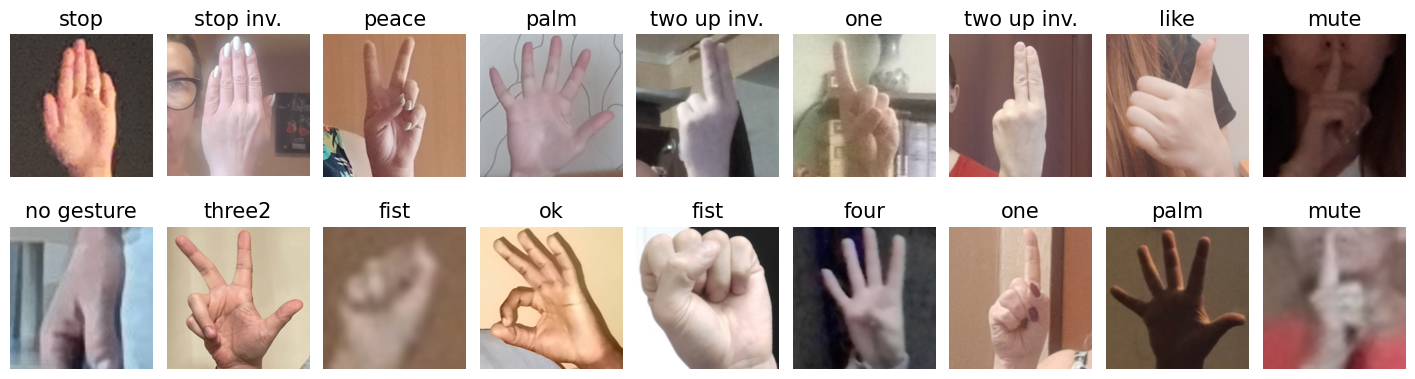

In [ ]:
short_class_names = []

for name in class_names:
    if name == 'stop_inverted':
        short_class_names.append('stop inv.')
    elif name == 'peace_inverted':
        short_class_names.append('peace inv.')
    elif name == 'two_up':
        short_class_names.append('two up')
    elif name == 'two_up_inverted':
        short_class_names.append('two up inv.')
    elif name == 'no_gesture':
        short_class_names.append('no gesture')
    else:
        short_class_names.append(name)

i = 0
plt.rcParams['figure.figsize'] = (18, 5)
plt.subplots_adjust(wspace=0, hspace=0)

for k in range(18):
    s = random.randint(0, len(test_data) - 1)
    sample = test_data[s]
    image = sample[0]
    label = sample[1]
    image = image.cpu()
    image = np.swapaxes(image, 0, 1)
    image = np.swapaxes(image, 1, 2)

    plt.subplot(2, 9, i + 1)
    plt.title(f"{short_class_names[label['gesture']]}", fontsize=15)
    plt.subplots_adjust(wspace=0.1, hspace=0)
    plt.imshow(image)
    plt.axis('off')
    i += 1
plt.show()


To gain a visual understanding of the hand gesture data, we have modified the class names for better visualization. The new class names facilitate clear labeling of each gesture and improve interpretability. The code snippet provided below demonstrates how we have created shortened class names.

Next, to visualize the diversity and complexity of the gestures present in the dataset, we have randomly selected 18 hand gesture images from the test dataset. For each selected sample, we display the image along with its corresponding gesture label using a 2x9 grid. The images are shown without axis ticks to maintain focus on the gesture representations.

By visualizing this random sample of test data, we gain an initial glimpse into the dataset's content, helping us better understand the variety of gestures present and their corresponding class labels.

In [ ]:
train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
                                               collate_fn=collate_fn, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
                                              collate_fn=collate_fn, shuffle=True)

torch.manual_seed(random_seed)
np.random.seed(random_seed)
random.seed(random_seed)

To facilitate training and evaluation, the data is loaded into dataloaders. We have created separate dataloaders for both the training and test datasets, each with a specified batch size. These dataloaders efficiently handle the data, ensuring that the models receive batches of images and corresponding labels during training and testing.
### **Challenging Aspects of the Data**
The hand gesture recognition task presents some challenges that need to be addressed for achieving accurate results. For example with hand gestures we deal with:
1.   Intra-class Variability: Different individuals may perform the same hand gesture with slight variations, leading to intra-class variability. The models need to generalize well and capture the essential features of each gesture, regardless of minor differences.
2.   Inter-class Similarity: Certain hand gestures might appear similar to others, making it difficult for the models to distinguish between them accurately. Ensuring that the models can discern even subtle differences between similar gestures is crucial for successful recognition.



## **Models and/or Methods**

In this section, we will showcase the judicious selection and appropriate application of the models and methods used for hand gesture recognition. We have opted for popular deep learning models, specifically ResNet18, ResNet50, VGG19, and VGG16, to explore their effectiveness in addressing the hand gesture recognition task. We felt that we could experiment and see what kind of loss function would give us the most accurate and generalized model. We will use the following loss functions and compare their results with each other:
1.   **Margin Loss**: Margin Loss introduces a margin hyperparameter that encourages the model to maintain a minimum separation between positive and negative examples. By optimizing for a larger margin, the model is incentivized to learn a decision boundary that pushes the classes apart, increasing the distinction between them. This can be particularly useful when dealing with classes that share similar characteristics, as it helps prevent misclassifications and improves the overall classification performance. We thought that this loss function will give us a good result with hand gesture recognition because as we have highlighted above it has alot of inter-class similarity
2.   **Cross Entropy Loss**:  Cross Entropy Loss measures the dissimilarity between the predicted probability distribution and the true probability distribution of the target classes. During training, the model learns to minimize the Cross-Entropy Loss, which encourages it to converge towards the correct probability distribution for each class. This loss function is effective in guiding the model to make more accurate predictions by penalizing incorrect classifications and assigning higher loss values to examples that deviate from the true distribution. We thought to use this as Cross-Entropy Loss is a standard choice for multi-class classification tasks and has proven to be effective in training deep learning models on diverse datasets.


###**Model Selection**:
We carefully selected these deep learning models based on their architectural features and performance characteristics, which are essential for accurately capturing intricate hand movements and gestures. The chosen models are as follows:

*   VGG19 and VGG16: VGG networks are renowned for their uniform and straightforward architecture, comprising repeated layers of small-sized filters. This simplicity makes VGG models easier to understand and implement, and they are often preferred for smaller datasets like HaGRID. Moreover, the uniformity in their structure can promote better generalization and reduce overfitting.

*   ResNet18 and ResNet50: These models are part of the ResNet family, known for their deep architecture with residual connections. Residual connections allow gradients to propagate effectively through the network, mitigating the vanishing gradient problem. As hand gesture recognition requires capturing subtle hand movements and fine details, the depth of ResNet18 and ResNet50 can facilitate feature extraction and representation, potentially leading to higher accuracy.


*   Densenet121: is a module designed to tackle the vanishing gradient problem by utilizing dense connectivity. In this architecture, each layer directly receives input from all preceding layers within a block. Through this dense connectivity, features can be reused and information can flow more efficiently. Thus, DenseNet achieves robust performance with fewer parameters while demonstrating improved parameter efficiency.

###**Model Training:**

Each model is trained on the hand gesture recognition dataset using the train_eval_model function. We specify the number of classes (num_classes) for the output layer of the model. The train_eval_model function takes care of initializing the model, defining the loss criterion, selecting an optimizer, and training the model for the specified number of epochs. The training progress, including accuracy and loss metrics, is recorded for evaluation. Below you can see we have trained a model for resnet18

In [ ]:
resnet18 = train_eval_model(num_classes, 'ResNet18', 'margin')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 347MB/s]

Loss type =  MarginLoss()


In [ ]:
%%time
train_accuracy_resnet18, train_loss_resnet18 = resnet18.training(10,train_dataloader=train_dataloader, print_epochs = 1)


epoch: 0, loss: 5.218
f1 gestures: 0.55, f1 leading hand: 0.483, epoch loss: 5.218, epoch accuracy: 0.056989021599292755
epoch: 1, loss: 3.218
f1 gestures: 0.654, f1 leading hand: 0.583, epoch loss: 3.218, epoch accuracy: 0.06662926077842712
epoch: 2, loss: 2.574
f1 gestures: 0.718, f1 leading hand: 0.609, epoch loss: 2.574, epoch accuracy: 0.07197549939155579
epoch: 3, loss: 1.904
f1 gestures: 0.78, f1 leading hand: 0.552, epoch loss: 1.904, epoch accuracy: 0.07795380055904388
epoch: 4, loss: 1.824
f1 gestures: 0.779, f1 leading hand: 0.612, epoch loss: 1.824, epoch accuracy: 0.07802469283342361
epoch: 5, loss: 1.686
f1 gestures: 0.819, f1 leading hand: 0.558, epoch loss: 1.686, epoch accuracy: 0.08175529539585114
epoch: 6, loss: 1.549
f1 gestures: 0.829, f1 leading hand: 0.582, epoch loss: 1.549, epoch accuracy: 0.08266925066709518
epoch: 7, loss: 1.529
f1 gestures: 0.869, f1 leading hand: 0.548, epoch loss: 1.529, epoch accuracy: 0.08676593005657196
epoch: 8, loss: 1.275
f1 gestures

###**Model Evaluation:**

After training each model, we evaluate its performance on the test dataset using the evaluate method. The evaluate method computes various evaluation metrics, including accuracy, precision, recall, and the confusion matrix. These metrics provide valuable insights into how well the models generalize to unseen data and their ability to distinguish between different hand gestures. Below you can see we are evaluating the resnet18 model trained above:

In [ ]:
df_cm_resnet18 = resnet18.evaluate(test_dataloader=test_dataloader)

=========start evaluate=========
f1 gestures: 0.641
f1 leading hand: 0.589
Accuracy: 0.662
Average Loss: 3.470


###**Model Saving:**

Once the training and evaluation processes are complete, we save each trained model in the desired location using the save_model method. This ensures that we can reuse the models later for inference or further experimentation without the need for retraining. Here we are saving the resnet18 model

In [ ]:
save_path = module_path+'/saved_models/trained_modelr18.h5'  # Replace this with the desired save path
resnet18.save_model(save_path)

Model saved to file: /content/drive/MyDrive/COMP9444_GroupProject/saved_models/trained_modelr18.h5


In [ ]:
resnet18_predictor = train_eval_model(num_classes, 'ResNet18', 'margin')

Loss type =  MarginLoss()


We can now go ahead and train, evaluate and save the other three models.

In [ ]:
resnet50 = train_eval_model(num_classes, 'ResNet50', 'margin')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 376MB/s]


Loss type =  MarginLoss()


In [ ]:
%%time
train_accuracy_resnet50, train_loss_resnet50 = resnet50.training(10,train_dataloader=train_dataloader, print_epochs = 1)

epoch: 0, loss: 17.511
f1 gestures: 0.15, f1 leading hand: 0.43, epoch loss: 17.511, epoch accuracy: 0.020081469789147377
epoch: 1, loss: 6.457
f1 gestures: 0.476, f1 leading hand: 0.556, epoch loss: 6.457, epoch accuracy: 0.04823773354291916
epoch: 2, loss: 3.239
f1 gestures: 0.685, f1 leading hand: 0.564, epoch loss: 3.239, epoch accuracy: 0.06774637848138809
epoch: 3, loss: 2.351
f1 gestures: 0.754, f1 leading hand: 0.503, epoch loss: 2.351, epoch accuracy: 0.07547169923782349
epoch: 4, loss: 2.379
f1 gestures: 0.755, f1 leading hand: 0.516, epoch loss: 2.379, epoch accuracy: 0.07259733974933624
epoch: 5, loss: 2.309
f1 gestures: 0.802, f1 leading hand: 0.453, epoch loss: 2.309, epoch accuracy: 0.08089730143547058
epoch: 6, loss: 1.669
f1 gestures: 0.805, f1 leading hand: 0.618, epoch loss: 1.669, epoch accuracy: 0.08131220936775208
epoch: 7, loss: 1.58
f1 gestures: 0.844, f1 leading hand: 0.565, epoch loss: 1.58, epoch accuracy: 0.08458437770605087
epoch: 8, loss: 1.337
f1 gestures

In [ ]:
df_cm_resnet50 = resnet50.evaluate(test_dataloader=test_dataloader)

=========start evaluate=========
f1 gestures: 0.637
f1 leading hand: 0.456
Accuracy: 0.640
Average Loss: 3.322


In [ ]:
save_path = module_path+'/saved_models/trained_modelr50.h5'  # Replace this with the desired save path
resnet50.save_model(save_path)

vgg19 = train_eval_model(num_classes, 'VGG19', 'margin')

Model saved to file: /content/drive/MyDrive/COMP9444_GroupProject/saved_models/trained_modelr50.h5


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:04<00:00, 135MB/s]


Loss type =  MarginLoss()


In [ ]:
%%time
train_accuracy_vgg19, train_loss_vgg19 = vgg19.training(10,train_dataloader=train_dataloader, print_epochs = 1)

epoch: 0, loss: 11.279
f1 gestures: 0.252, f1 leading hand: 0.588, epoch loss: 11.279, epoch accuracy: 0.030358141288161278
epoch: 1, loss: 3.094
f1 gestures: 0.593, f1 leading hand: 0.843, epoch loss: 3.094, epoch accuracy: 0.06278757005929947
epoch: 2, loss: 1.376
f1 gestures: 0.771, f1 leading hand: 0.885, epoch loss: 1.376, epoch accuracy: 0.07745350897312164
epoch: 3, loss: 0.971
f1 gestures: 0.837, f1 leading hand: 0.886, epoch loss: 0.971, epoch accuracy: 0.08303850144147873
epoch: 4, loss: 0.696
f1 gestures: 0.868, f1 leading hand: 0.915, epoch loss: 0.696, epoch accuracy: 0.08564942330121994
epoch: 5, loss: 0.465
f1 gestures: 0.9, f1 leading hand: 0.947, epoch loss: 0.465, epoch accuracy: 0.08971523493528366
epoch: 6, loss: 0.316
f1 gestures: 0.936, f1 leading hand: 0.958, epoch loss: 0.316, epoch accuracy: 0.09266914427280426
epoch: 7, loss: 0.34
f1 gestures: 0.933, f1 leading hand: 0.961, epoch loss: 0.34, epoch accuracy: 0.09340506047010422
epoch: 8, loss: 0.194
f1 gestures

In [ ]:
df_cm_vgg19 = vgg19.evaluate(test_dataloader=test_dataloader)

=========start evaluate=========
f1 gestures: 0.804
f1 leading hand: 0.893
Accuracy: 0.804
Average Loss: 1.363


In [ ]:
save_path = module_path+'/saved_models/trained_modelv19.h5'  # Replace this with the desired save path
vgg19.save_model(save_path)

vgg16 = train_eval_model(num_classes, 'VGG16', 'margin')

Model saved to file: /content/drive/MyDrive/COMP9444_GroupProject/saved_models/trained_modelv19.h5


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:01<00:00, 288MB/s]


Loss type =  MarginLoss()


In [ ]:
%%time
train_accuracy_vgg16, train_loss_vgg16 = vgg16.training(10,train_dataloader=train_dataloader, print_epochs = 1)

epoch: 0, loss: 11.218
f1 gestures: 0.229, f1 leading hand: 0.592, epoch loss: 11.218, epoch accuracy: 0.027152830734848976
epoch: 1, loss: 2.456
f1 gestures: 0.654, f1 leading hand: 0.868, epoch loss: 2.456, epoch accuracy: 0.0677257552742958
epoch: 2, loss: 1.483
f1 gestures: 0.784, f1 leading hand: 0.843, epoch loss: 1.483, epoch accuracy: 0.07912363857030869
epoch: 3, loss: 0.839
f1 gestures: 0.863, f1 leading hand: 0.88, epoch loss: 0.839, epoch accuracy: 0.08514144271612167
epoch: 4, loss: 0.502
f1 gestures: 0.914, f1 leading hand: 0.93, epoch loss: 0.502, epoch accuracy: 0.09198708832263947
epoch: 5, loss: 0.298
f1 gestures: 0.948, f1 leading hand: 0.968, epoch loss: 0.298, epoch accuracy: 0.09517802298069
epoch: 6, loss: 0.289
f1 gestures: 0.949, f1 leading hand: 0.958, epoch loss: 0.289, epoch accuracy: 0.09461721032857895
epoch: 7, loss: 0.212
f1 gestures: 0.963, f1 leading hand: 0.963, epoch loss: 0.212, epoch accuracy: 0.09540293365716934
epoch: 8, loss: 0.185
f1 gestures: 

In [ ]:
df_cm_vgg16 = vgg16.evaluate(test_dataloader=test_dataloader) # data frame _ confusion matrix

save_path = module_path+'/saved_models/trained_modelv16.h5'  # Replace this with the desired save path
vgg16.save_model(save_path)

=========start evaluate=========
f1 gestures: 0.845
f1 leading hand: 0.897
Accuracy: 0.845
Average Loss: 1.283
Model saved to file: /content/drive/MyDrive/COMP9444_GroupProject/saved_models/trained_modelv16.h5


In [ ]:
Densenet = train_eval_model(num_classes, 'Densenet', 'margin')

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 74.2MB/s]

Loss type =  MarginLoss()


In [ ]:
%%time
train_accuracy_densenet, train_loss_densenet = Densenet.training(10,train_dataloader=train_dataloader, print_epochs = 1)

epoch: 0, loss: 8.473
f1 gestures: 0.382, f1 leading hand: 0.501, epoch loss: 8.473, epoch accuracy: 0.04048270359635353
epoch: 1, loss: 2.37
f1 gestures: 0.749, f1 leading hand: 0.579, epoch loss: 2.37, epoch accuracy: 0.07376880198717117
epoch: 2, loss: 1.645
f1 gestures: 0.821, f1 leading hand: 0.614, epoch loss: 1.645, epoch accuracy: 0.08202528208494186
epoch: 3, loss: 1.279
f1 gestures: 0.868, f1 leading hand: 0.666, epoch loss: 1.279, epoch accuracy: 0.08774147927761078
epoch: 4, loss: 1.236
f1 gestures: 0.904, f1 leading hand: 0.607, epoch loss: 1.236, epoch accuracy: 0.09102410823106766
epoch: 5, loss: 0.996
f1 gestures: 0.925, f1 leading hand: 0.677, epoch loss: 0.996, epoch accuracy: 0.09129834175109863
epoch: 6, loss: 0.949
f1 gestures: 0.934, f1 leading hand: 0.658, epoch loss: 0.949, epoch accuracy: 0.09327003359794617
epoch: 7, loss: 0.933
f1 gestures: 0.955, f1 leading hand: 0.674, epoch loss: 0.933, epoch accuracy: 0.09433050453662872
epoch: 8, loss: 1.065
f1 gestures:

In [ ]:
df_cm_Densenet = Densenet.evaluate(test_dataloader=test_dataloader)

=========start evaluate=========
f1 gestures: 0.656
f1 leading hand: 0.505
Accuracy: 0.654
Average Loss: 2.956


In [ ]:
save_path = module_path+'/saved_models/trained_modeldense.h5'  # Replace this with the desired save path
Densenet.save_model(save_path)

Model saved to file: /content/drive/MyDrive/COMP9444_GroupProject/saved_models/trained_modeldense.h5


In [ ]:
%%time
resnet18_cross = train_eval_model(num_classes, 'ResNet18', 'cross')
train_accuracy_resnet18_cross, train_loss_resnet18_corss = resnet18_cross.training(10,train_dataloader=train_dataloader, print_epochs = 0)
df_cm_resnet18_cross = resnet18_cross.evaluate(test_dataloader=test_dataloader)
save_path = module_path+'/saved_models/trained_modelr18_cross.h5'  # Replace this with the desired save path
resnet18_cross.save_model(save_path)


Loss type =  CrossEntropyLoss()
=========start evaluate=========
f1 gestures: 0.616
f1 leading hand: 0.557
Accuracy: 0.627
Average Loss: 1.242
Model saved to file: /content/drive/MyDrive/COMP9444_GroupProject/saved_models/trained_modelr18_cross.h5
CPU times: user 14min 9s, sys: 15.5 s, total: 14min 24s
Wall time: 12min 33s


In [ ]:
%%time
resnet50_cross = train_eval_model(num_classes, 'ResNet50', 'cross')
train_accuracy_resnet50_cross, train_loss_resnet50_corss = resnet50_cross.training(10,train_dataloader=train_dataloader, print_epochs = 0)
df_cm_resnet50_cross = resnet50_cross.evaluate(test_dataloader=test_dataloader)
save_path = module_path+'/saved_models/trained_modelr50_cross.h5'  # Replace this with the desired save path
resnet50_cross.save_model(save_path)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 132MB/s]


Loss type =  CrossEntropyLoss()
=========start evaluate=========
f1 gestures: 0.576
f1 leading hand: 0.504
Accuracy: 0.589
Average Loss: 1.393
Model saved to file: /content/drive/MyDrive/COMP9444_GroupProject/saved_models/trained_modelr50_cross.h5
CPU times: user 14min 20s, sys: 15.1 s, total: 14min 35s
Wall time: 10min 49s


In [ ]:
%%time
VGG16_cross = train_eval_model(num_classes, 'VGG16', 'cross')
train_accuracy_VGG16_cross, train_loss_VGG16_corss = VGG16_cross.training(10,train_dataloader=train_dataloader, print_epochs = 0)
df_cm_VGG16_cross = VGG16_cross.evaluate(test_dataloader=test_dataloader)
save_path = module_path+'/saved_models/trained_modelVGG16_cross.h5'  # Replace this with the desired save path
VGG16_cross.save_model(save_path)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:08<00:00, 65.0MB/s]


Loss type =  CrossEntropyLoss()
=========start evaluate=========
f1 gestures: 0.857
f1 leading hand: 0.874
Accuracy: 0.858
Average Loss: 0.482
Model saved to file: /content/drive/MyDrive/COMP9444_GroupProject/saved_models/trained_modelVGG16_cross.h5
CPU times: user 14min 58s, sys: 18.1 s, total: 15min 16s
Wall time: 11min 39s


In [ ]:
%%time
VGG19_cross = train_eval_model(num_classes, 'VGG19', 'cross')
train_accuracy_VGG19_cross, train_loss_VGG19_corss = VGG19_cross.training(10,train_dataloader=train_dataloader, print_epochs = 0)
df_cm_VGG19_cross = VGG19_cross.evaluate(test_dataloader=test_dataloader)
save_path = module_path+'/saved_models/trained_modelVGG19_cross.h5'  # Replace this with the desired save path
VGG16_cross.save_model(save_path)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:09<00:00, 61.6MB/s]


Loss type =  CrossEntropyLoss()
=========start evaluate=========
f1 gestures: 0.833
f1 leading hand: 0.847
Accuracy: 0.837
Average Loss: 0.571
Model saved to file: /content/drive/MyDrive/COMP9444_GroupProject/saved_models/trained_modelVGG19_cross.h5
CPU times: user 15min 13s, sys: 18.4 s, total: 15min 32s
Wall time: 11min 50s


In [ ]:
%%time
Densenet_cross = train_eval_model(num_classes, 'Densenet', 'cross')
train_accuracy_Densenet_cross, train_loss_Densenet_corss = Densenet_cross.training(10,train_dataloader=train_dataloader, print_epochs = 0)
df_cm_Densenet_cross = Densenet_cross.evaluate(test_dataloader=test_dataloader)
save_path = module_path+'/saved_models/trained_modelDensenet_cross.h5'  # Replace this with the desired save path
Densenet_cross.save_model(save_path)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 60.6MB/s]


Loss type =  CrossEntropyLoss()
=========start evaluate=========
f1 gestures: 0.66
f1 leading hand: 0.644
Accuracy: 0.665
Average Loss: 1.033
Model saved to file: /content/drive/MyDrive/COMP9444_GroupProject/saved_models/trained_modelDensenet_cross.h5
CPU times: user 14min 27s, sys: 15.6 s, total: 14min 42s
Wall time: 10min 56s


Now that we have trained and evaluated our models we can now perform inference on a set of new images. We will use the trained ResNet18 model to do this.

In [ ]:
import torchvision.transforms as transforms
import cv2

# Step 1: Read the image using OpenCV

directory_path = '/content/drive/MyDrive/COMP9444_GroupProject/dataset/test'
def get_jpg_files(directory_path):
    jpg_files = [file for file in os.listdir(directory_path) if file.lower().endswith('.jpg')]
    jpg_files_with_paths = [os.path.join(directory_path, file) for file in jpg_files]
    return jpg_files, jpg_files_with_paths

# Step 1: Read the images using OpenCV
_, image_paths = get_jpg_files(directory_path)

# Step 2: Resize the images to the desired size (e.g., 224x224)
desired_size = (224, 224)
resized_images = [cv2.resize(cv2.imread(path), desired_size) for path in image_paths]

# Step 3: Convert the images to NumPy arrays and normalize pixel values to [0, 1]
normalized_images = [image.astype(np.float32) / 255.0 for image in resized_images]

# Step 4: Convert the NumPy arrays to PyTorch tensors and apply transformations
# First, convert each NumPy array to a PyTorch tensor with the desired shape [3, 224, 224]
tensor_images = [torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) for image in normalized_images]

# Convert the list of tensors to a tuple
tuple_of_images = tuple(tensor_images)

# Print the final shape of the first image in the tuple
print(tuple_of_images[0].shape)  # Output: torch.Size([3, 224, 224])
print(len(tuple_of_images))

torch.Size([3, 224, 224])
3


The steps we go through in the above code is explained below:

**Step 1: Read and Prepare Images**

The code starts by defining a directory path (directory_path) where the new images for inference are stored.
The function get_jpg_files reads the file names with the extension ".jpg" from the specified directory and returns two lists: jpg_files, containing the file names, and jpg_files_with_paths, containing the complete file paths.
The file names and paths are stored in two variables (_, image_paths) using the _ placeholder for unused variables.
The desired size for the images is set to 224x224 pixels (desired_size).
The images are resized using OpenCV's resize function to the desired size, and the resized images are stored in the list resized_images.

**Step 2: Normalize and Convert Images**
The code then proceeds to convert the images to NumPy arrays and normalize the pixel values to the range [0, 1]. Each image in resized_images is converted to a NumPy array of dtype np.float32, and the pixel values are divided by 255 to normalize them.

**Step 3: Convert to PyTorch Tensors**

In this step, the NumPy arrays are converted to PyTorch tensors and reshaped to the desired shape [3, 224, 224]. Each NumPy array in normalized_images is converted to a PyTorch tensor using torch.tensor with dtype torch.float32. The permute(2, 0, 1) function is used to swap the dimensions of the tensor to match the expected format [channels, height, width] required by the ResNet18 model.

**Step 4: Prepare Input Data for Inference**

The list of PyTorch tensors (tensor_images) is converted into a tuple (tuple_of_images) to be used as input for the ResNet18 model's inference.



The predicted class indices are then mapped to their corresponding class names using the class_names list, and the names are printed for each prediction.
To visualize the inference results, the code randomly selects three samples from the test data (test_data) and displays the original images along with their corresponding predicted class names using matplotlib.

mute
peace_inverted
peace_inverted


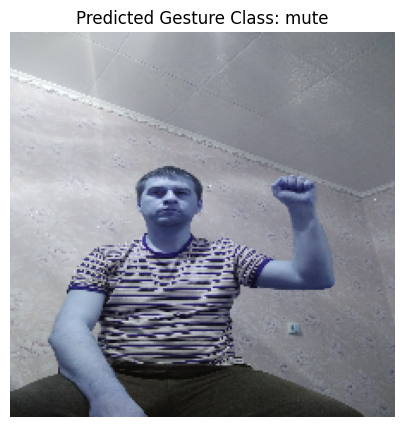

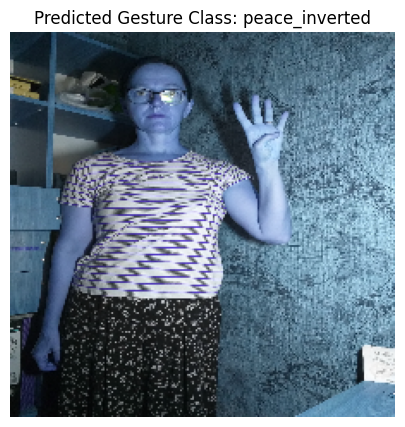

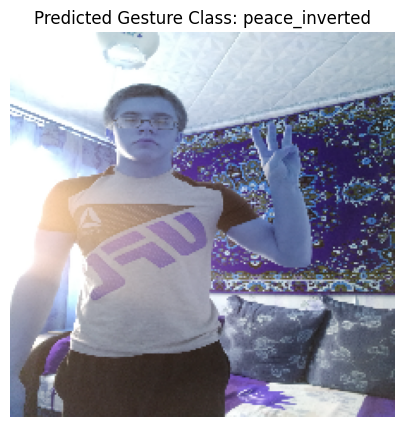

In [ ]:

predictions, images_return = Densenet.predict(tuple_of_images)
for pred in predictions:
  print(class_names[pred])
# Plot images_return with predicted_gesture
for i in range(len(images_return)):
    image = images_return[i].cpu().numpy()  # Convert the tensor back to a NumPy array
    class_name = class_names[predictions[i].item()]  # Access the class name from class_names

    plt.imshow(np.transpose(image, (1, 2, 0)))  # Transpose the image to (H, W, C) format for plotting
    plt.title(f"Predicted Gesture Class: {class_name}")
    plt.axis('off')
    plt.show()

We used predict method of the resnet18 model, passing the tuple of images (tuple_of_images) as input. This returns the predicted class indices for each image in the tuple.

To visualize the inference results, the code randomly selects three samples from the test data (test_data) and displays the original images along with their corresponding predicted class names using matplotlib.

##**Result**
Here are five images of confusion matrix of each model, which are resnet18, resnet50, vgg19, vgg16 and Densenet respectively. These matrices illustrate how well each model correctly identifies hand gestures. The diagonal elements of the matrix indicate the number of correct predictions for each gesture, while off-diagonal elements show the misclassifications.

<Figure size 1000x800 with 0 Axes>

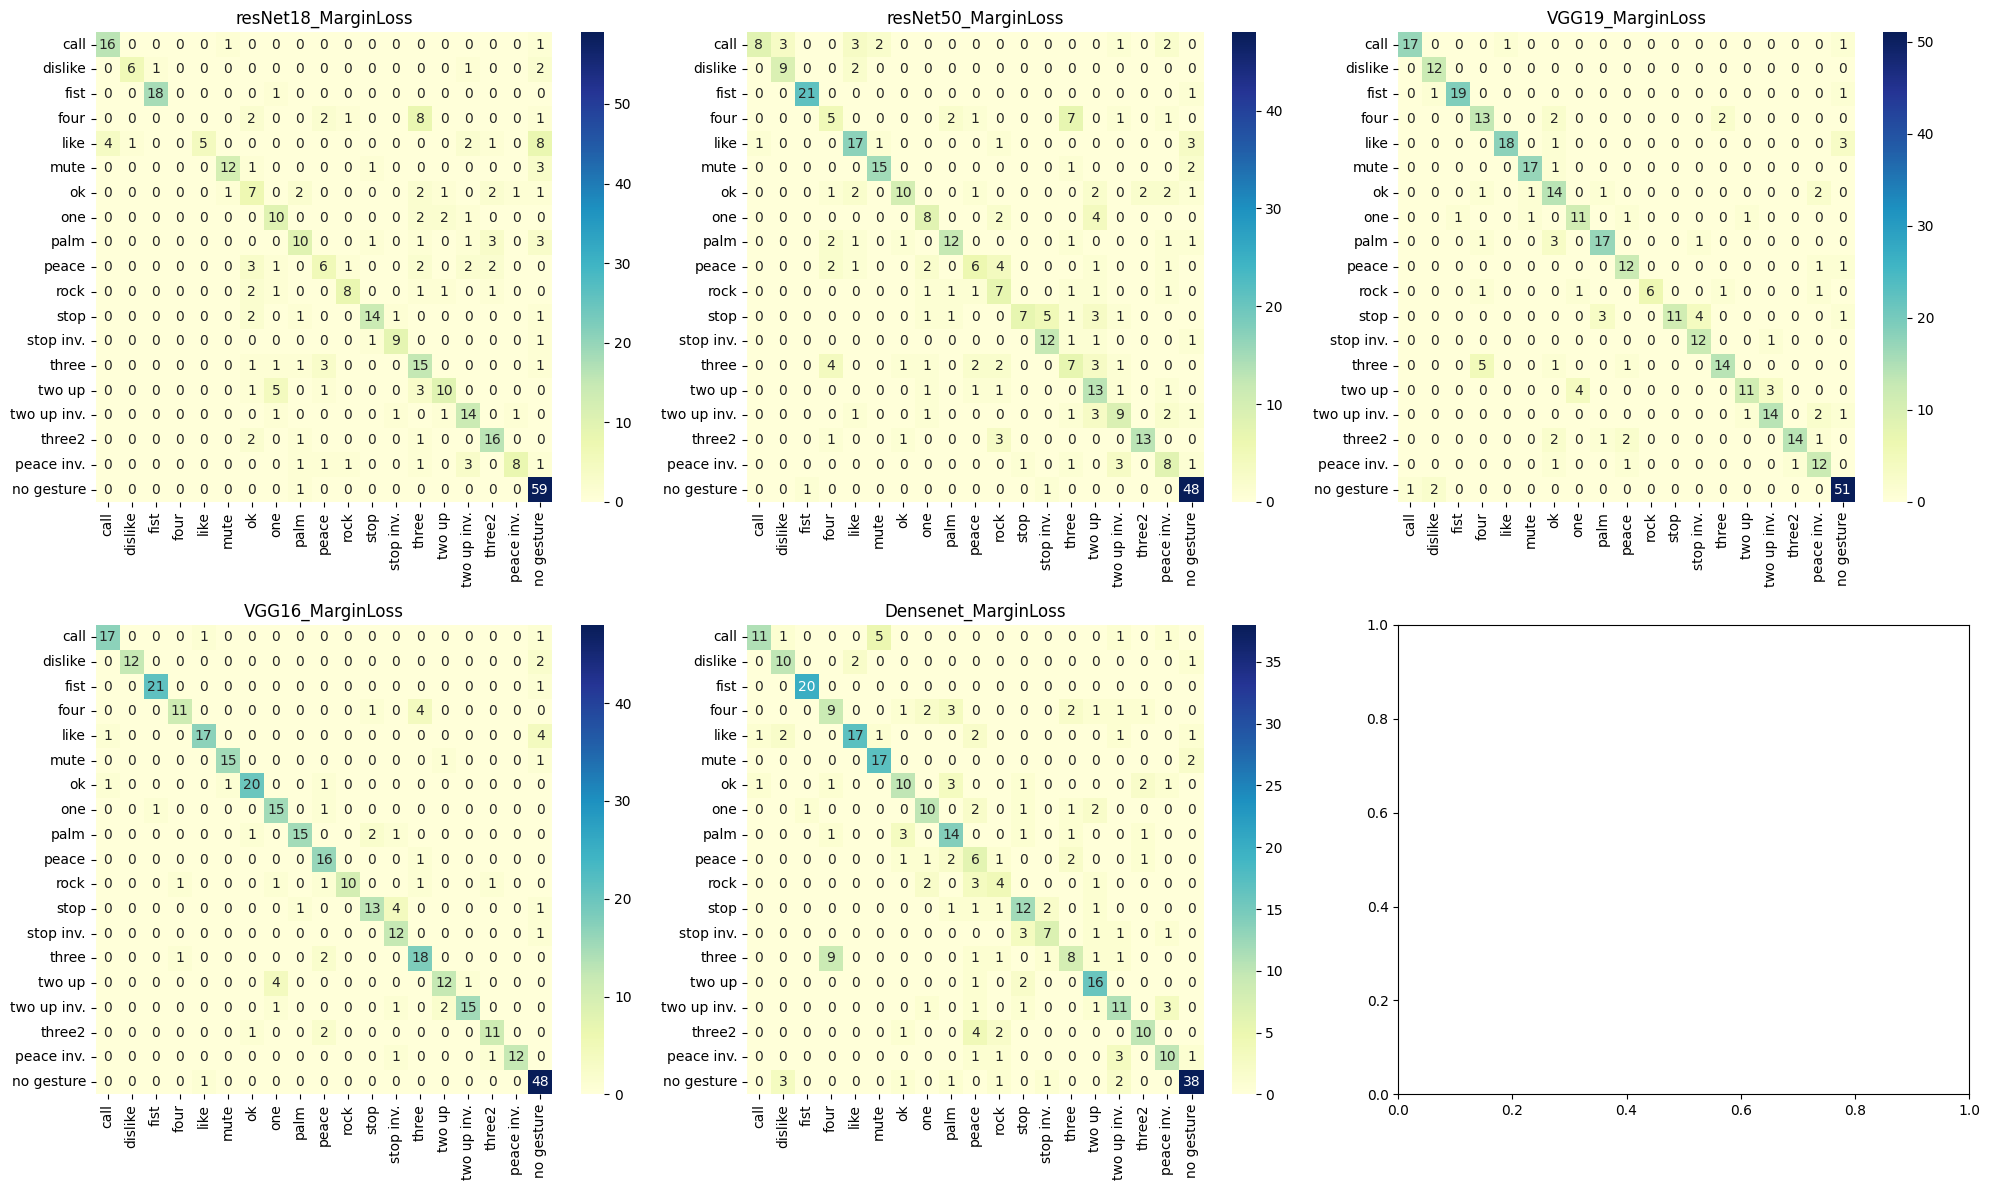

In [ ]:
plt.figure(figsize=(10, 8))
models_data = {
    'resNet18_MarginLoss': df_cm_resnet18,
    'resNet50_MarginLoss': df_cm_resnet50,
    'VGG19_MarginLoss': df_cm_vgg19,
    'VGG16_MarginLoss': df_cm_vgg16,
    'Densenet_MarginLoss': df_cm_Densenet
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for i, (model_name, df_cm) in enumerate(models_data.items()):
    row, col = i // 3, i % 3
    ax = axes[row, col]

    hm = sns.heatmap(df_cm, annot=True, fmt='.5g', cmap='YlGnBu', ax=ax)
    hm.set_title(model_name)

plt.tight_layout()
plt.show()
###################################################################################################

### Below them, there are two parallel line charts, whose xlabel is epoch and ylabel is Accuracy and Loss.

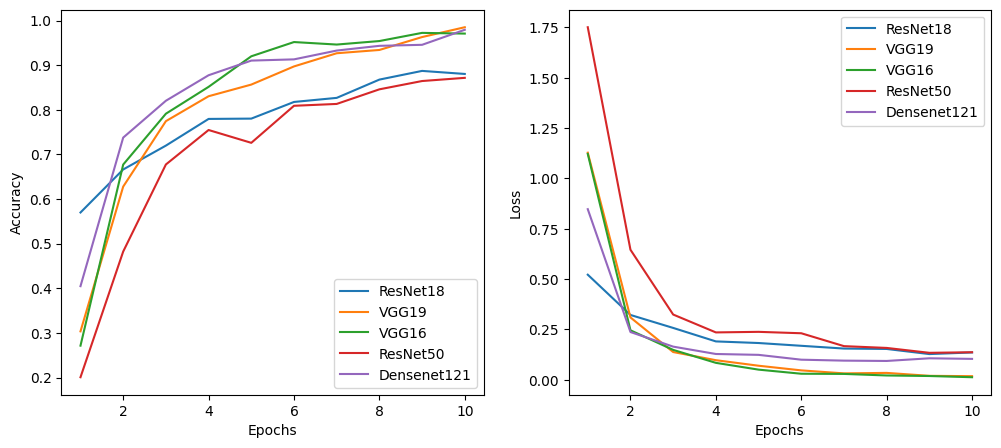

In [ ]:
train_accuracy_resnet18 = [tensor.cpu() for tensor in train_accuracy_resnet18]
# Convert the list of tensors to a single PyTorch tensor
train_accuracy_tensor = torch.cat([tensor.unsqueeze(0) for tensor in train_accuracy_resnet18])
# Convert the PyTorch tensor to a NumPy array
train_accuracy_numpy_resnet18_cross = train_accuracy_tensor.numpy()

train_accuracy_resnet50 = [tensor.cpu() for tensor in train_accuracy_resnet50]
# Convert the list of tensors to a single PyTorch tensor
train_accuracy_tensor = torch.cat([tensor.unsqueeze(0) for tensor in train_accuracy_resnet50])
# Convert the PyTorch tensor to a NumPy array
train_accuracy_numpy_resnet50 = train_accuracy_tensor.numpy()

train_accuracy_vgg16 = [tensor.cpu() for tensor in train_accuracy_vgg16]
# Convert the list of tensors to a single PyTorch tensor
train_accuracy_tensor = torch.cat([tensor.unsqueeze(0) for tensor in train_accuracy_vgg16])
# Convert the PyTorch tensor to a NumPy array
train_accuracy_numpy_vgg16_cross = train_accuracy_tensor.numpy()

train_accuracy_vgg19 = [tensor.cpu() for tensor in train_accuracy_vgg19]
# Convert the list of tensors to a single PyTorch tensor
train_accuracy_tensor = torch.cat([tensor.unsqueeze(0) for tensor in train_accuracy_vgg19])
# Convert the PyTorch tensor to a NumPy array
train_accuracy_numpy_vgg19 = train_accuracy_tensor.numpy()

train_accuracy_densenet = [tensor.cpu() for tensor in train_accuracy_densenet]
# Convert the list of tensors to a single PyTorch tensor
train_accuracy_tensor = torch.cat([tensor.unsqueeze(0) for tensor in train_accuracy_densenet])
# Convert the PyTorch tensor to a NumPy array
train_accuracy_numpy_densenet = train_accuracy_tensor.numpy()



num_epochs= np.arange(1, epochs+1)
num_epochs = np.arange(1,11)
plt.figure(figsize=(12, 5))


# Plot train accuracy
plt.subplot(1, 2, 1)
plt.plot(num_epochs, train_accuracy_resnet18, label='ResNet18')
plt.plot(num_epochs, train_accuracy_vgg19, label='VGG19')
plt.plot(num_epochs, train_accuracy_vgg16, label='VGG16')
plt.plot(num_epochs, train_accuracy_resnet50, label='ResNet50')
plt.plot(num_epochs, train_accuracy_densenet, label='Densenet121')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot train loss
plt.subplot(1, 2, 2)
plt.plot(num_epochs, train_loss_resnet18, label='ResNet18')
plt.plot(num_epochs, train_loss_vgg19, label='VGG19')
plt.plot(num_epochs, train_loss_vgg16, label='VGG16')
plt.plot(num_epochs, train_loss_resnet50, label='ResNet50')
plt.plot(num_epochs, train_loss_densenet, label='Densenet121')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
!pip install torchsummary
!pip install torchviz


  Preparing metadata (setup.py) ... done
  Created wheel for torchviz: filename=torchviz-0.0.2-py3-none-any.whl size=4131 sha256=7aaeb12c9a461929d2110e6e039e5c6cd0c46f025ebe17f8a67bf36dcfd8cfc2
  Stored in directory: /root/.cache/pip/wheels/4c/97/88/a02973217949e0db0c9f4346d154085f4725f99c4f15a87094
Successfully built torchviz


In [ ]:
from torchsummary import summary
from torchviz import make_dot

# Print the model summary
summary(vgg19.model, (3, 224, 224))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [ ]:
# Calculate the total number of trainable parameters
num_trainable_params = sum(p.numel() for p in Densenet.model.parameters() if p.requires_grad)
num_non_trainable_params = sum(p.numel() for p in Densenet.model.parameters() if not p.requires_grad)

print(num_trainable_params)
print(num_non_trainable_params)

<Figure size 1000x800 with 0 Axes>

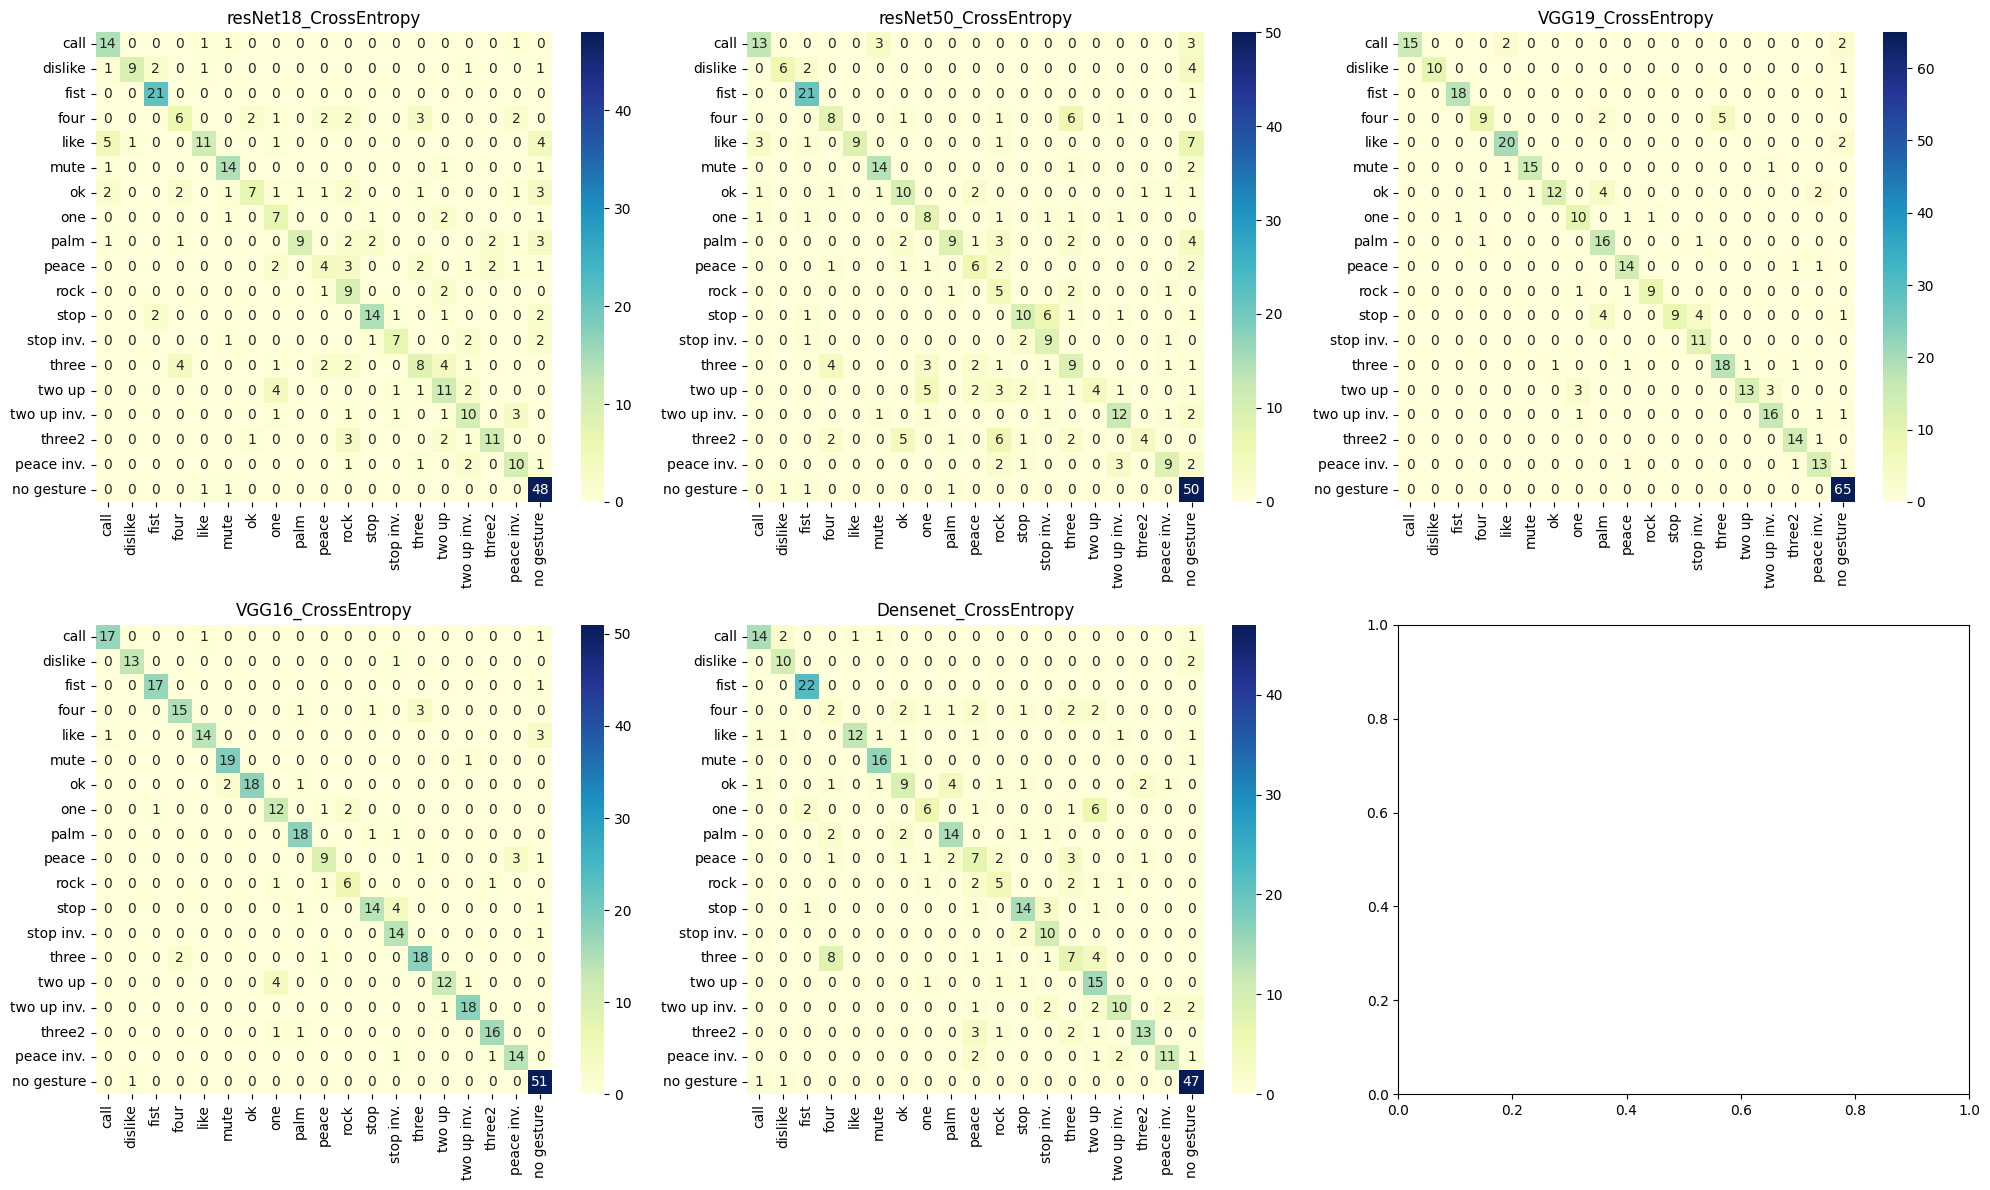

In [ ]:
plt.figure(figsize=(10, 8))
models_data = {
    'resNet18_CrossEntropy': df_cm_resnet18_cross,
    'resNet50_CrossEntropy': df_cm_resnet50_cross,
    'VGG19_CrossEntropy': df_cm_VGG19_cross,
    'VGG16_CrossEntropy': df_cm_VGG16_cross,
    'Densenet_CrossEntropy': df_cm_Densenet_cross
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for i, (model_name, df_cm) in enumerate(models_data.items()):
    row, col = i // 3, i % 3
    ax = axes[row, col]

    hm = sns.heatmap(df_cm, annot=True, fmt='.5g', cmap='YlGnBu', ax=ax)
    hm.set_title(model_name)

plt.tight_layout()
plt.show()



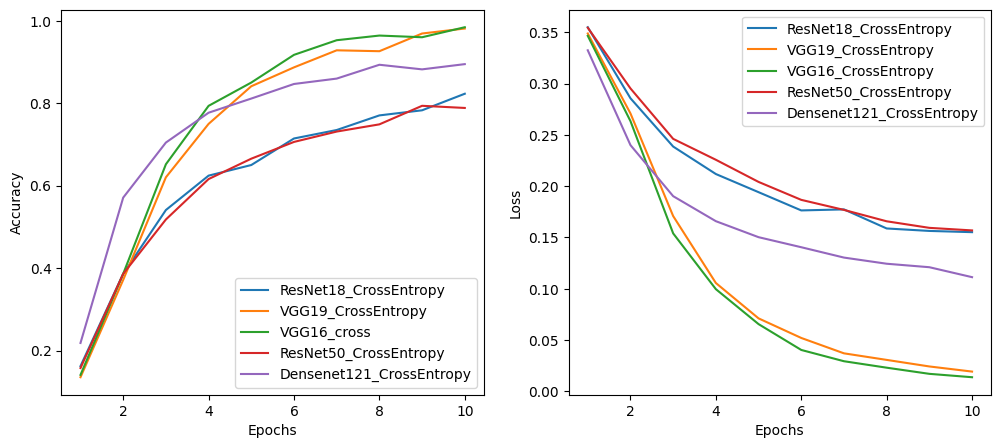

In [ ]:
train_accuracy_resnet18_cross = [tensor.cpu() for tensor in train_accuracy_resnet18_cross]
# Convert the list of tensors to a single PyTorch tensor
train_accuracy_tensor = torch.cat([tensor.unsqueeze(0) for tensor in train_accuracy_resnet18_cross])
# Convert the PyTorch tensor to a NumPy array
train_accuracy_numpy_resnet18_cross = train_accuracy_tensor.numpy()

train_accuracy_resnet50_cross = [tensor.cpu() for tensor in train_accuracy_resnet50_cross]
# Convert the list of tensors to a single PyTorch tensor
train_accuracy_tensor = torch.cat([tensor.unsqueeze(0) for tensor in train_accuracy_resnet50_cross])
# Convert the PyTorch tensor to a NumPy array
train_accuracy_numpy_resnet50_cross = train_accuracy_tensor.numpy()

train_accuracy_VGG16_cross = [tensor.cpu() for tensor in train_accuracy_VGG16_cross]
# Convert the list of tensors to a single PyTorch tensor
train_accuracy_tensor = torch.cat([tensor.unsqueeze(0) for tensor in train_accuracy_VGG16_cross])
# Convert the PyTorch tensor to a NumPy array
train_accuracy_numpy_vgg16_cross = train_accuracy_tensor.numpy()

train_accuracy_VGG19_cross = [tensor.cpu() for tensor in train_accuracy_VGG19_cross]
# Convert the list of tensors to a single PyTorch tensor
train_accuracy_tensor = torch.cat([tensor.unsqueeze(0) for tensor in train_accuracy_VGG19_cross])
# Convert the PyTorch tensor to a NumPy array
train_accuracy_numpy_vgg19_cross = train_accuracy_tensor.numpy()

train_accuracy_Densenet_cross = [tensor.cpu() for tensor in train_accuracy_Densenet_cross]
# Convert the list of tensors to a single PyTorch tensor
train_accuracy_tensor = torch.cat([tensor.unsqueeze(0) for tensor in train_accuracy_Densenet_cross])
# Convert the PyTorch tensor to a NumPy array
train_accuracy_numpy_densenet_cross = train_accuracy_tensor.numpy()



num_epochs= np.arange(1, epochs+1)
num_epochs = np.arange(1,11)
plt.figure(figsize=(12, 5))


# Plot train accuracy
plt.subplot(1, 2, 1)
plt.plot(num_epochs, train_accuracy_resnet18_cross, label='ResNet18_CrossEntropy')
plt.plot(num_epochs, train_accuracy_VGG19_cross, label='VGG19_CrossEntropy')
plt.plot(num_epochs, train_accuracy_VGG16_cross, label='VGG16_cross')
plt.plot(num_epochs, train_accuracy_resnet50_cross, label='ResNet50_CrossEntropy')
plt.plot(num_epochs, train_accuracy_Densenet_cross, label='Densenet121_CrossEntropy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot train loss
plt.subplot(1, 2, 2)
plt.plot(num_epochs, train_loss_resnet18_corss, label='ResNet18_CrossEntropy')
plt.plot(num_epochs, train_loss_VGG19_corss, label='VGG19_CrossEntropy')
plt.plot(num_epochs, train_loss_VGG16_corss, label='VGG16_CrossEntropy')
plt.plot(num_epochs, train_loss_resnet50_corss, label='ResNet50_CrossEntropy')
plt.plot(num_epochs, train_loss_Densenet_corss, label='Densenet121_CrossEntropy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## **Discussion**
### **Analyze**
According to results of this experiment, we can discuss from two aspects:
#### *1. Confusion Matrix*
Generally, "no gesture" is obviously determined by each model. \\
Let's first discuss the results of the cross-entropy models from top to bottom and will then go through the margin loss models
It seems the resNet18 cross-entropy loss model can correctly predict a 'fist' every time, but 'peace' is confused easily with 'three', 'ok', 'three2' and 'peace_inv' due to the number of fingers. \\
In the graph of resNet50, 'fist' is still easily determined even if there is a little confusion with 'no_gesture'. However, compared by resNet18, successful rates for other gestures decrease. \\
As for VGG16 and VGG19, by comparison with resNet18, they both seem to have predicted hand gestures better compared to the resnet models and densenet. However, these models have still struggled with gestures like 'peace' and 'rock'. This is because these gestures all have features that are common to others (Inter-class similarity). For example, despite having the best predictions out of all the models VGG16 still struggled to identify 'peace' frequently mistaking it for 'peace_inv'

We can now take a look at the confusion matrices for the models when we were using margin loss. ResNet18 and ResNet50 have not performed that well, with ResNet18 failing to identify 'four' correctly every single time it was asked to predict. However, it seems that they have performed overall better than their cross-entropy models. We can see that ResNet18 with margin loss does a better job of predicting 'one' and 'stop_inv' than the other models.
However, where we really see the difference of using margin loss is in the VGG models. With VGG19 we have improvements across the board with better prediction of gestures like 'call' and 'mute'. VGG16 has the best performance, with it managing to classify tricky gestures that all other models struggled with such as 'peace' and 'rock'
#### *2. Accuracy and Loss*
When considering accuracy and loss we will start by discussing the cross-entropy loss model results, followed by the margin loss results.
We can see that out of the cross-entropy models VGG16 has the highest accuracy, while VGG19 follows close behind. ResNet50 and ResNet18 both have an accuracy below 80% with ResNet18 performing slightly better.

When we take a look at their loss chart, after 10 epoches, VGG16 has the lowest loss close to 0.01 followed by VGG19. ResNet50 and ResNet18 have a loss of around 0.17 and have thus performed significantly worse. We were already able to identify this from the confusion matrices but this confirms that the ResNet Cross-Entropy Loss Models are unable to adequately distinguish between different types of hand gestures - especially when they have similar characteristics. We can also observe that the loss graphs of all of these models are quite smooth, decreasing gradually over the course of the 10 epochs

We can now discuss the margin loss models accuracy and loss results. We see an improvement of accuracy across the board with VGG16 and VGG19 performing even better than the cross-entropy models. DenseNet50 had a great improvement going from an accuracy closer to 90% to one close to 100%. Even ResNet18 and ResNet50 see an improvement going from less than 80% accuracy to around 85%.

From the loss graphs for margin loss we can see that they are different from the cross-entropy models. Here the loss plunges rapidly in the first few epochs and then the graph is fairly flat with not too much movement from the 4th epoch onwards. Thus, there is not as much variability in the final loss of each model. With this loss function all of the models have low loss below 0.25 with ResNet50 having the greatest loss and VGG16 having the least loss.





## **Conclusion**
After training and testing various hand gesture recognition models, it is evident that VGG16 stands out as the best model for this task. It achieved the highest accuracy rate and the lowest loss value compared to other models, including VGG19 and ResNet, despite their more complex convolutional layers and advanced architectures. VGG16's relatively simple structure, which employs multiple small convolutional kernels and 2x2 pooling layers stacked multiple times, proves to be effective in achieving accurate results.

###**Insights and Strengths**:

VGG16's simplicity in architecture makes it easy to understand and implement, yet it performs exceptionally well in hand gesture recognition, outperforming more complex models.
The margin loss function significantly improved the accuracy of the models, particularly for VGG16, VGG19, and DenseNet50, making them more robust in distinguishing gestures with similar characteristics.
VGG16 and VGG19 showed remarkable improvements with the margin loss function, correctly classifying even challenging gestures like 'peace' and 'rock'.
###**Weaknesses and Limitations**:

The conclusion is limited by the dataset size. VGG16 may be less prone to overfitting compared to deeper models, especially when the dataset is not large enough to handle the complexity of more intricate architectures.
Computing resources can be a limitation, especially for models like VGG19, which require more parameters and longer training times. Inadequate training time or suboptimal hyperparameters could affect their performance.
Possible Future Work:

Researchers can experiment with variations of the VGG16 architecture, such as adding skip connections (e.g., residual connections from ResNet), to improve training and alleviate the vanishing gradient problem.
Exploring different kernel sizes, pooling strategies, or adding attention mechanisms may lead to improved performance for hand gesture recognition.
Overall, the study emphasizes the significance of the choice of loss function in hand gesture recognition models. The margin loss function, in particular, proved to be effective in improving accuracy and loss convergence for several architectures. While VGG16 showed outstanding performance, further research and experimentation with different architectures and loss functions can help refine and enhance the models' performance for real-world applications. The system information, which includes a Tesla T4 GPU with CUDA 12.0, suggests that the system is well-equipped for training and testing deep learning models, enabling researchers and developers to explore advanced architectures and large datasets to enhance the hand gesture recognition system further.
